# Electrode characterization

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root, so `import src...` works

import numpy as np
import pandas as pd
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.cm as cm

from scipy import signal, stats
from scipy.optimize import curve_fit

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from IPython.display import display, Image

from src import config as cfg
from src import ecog_cnn as ec
from src.io_utils import save_fig, save_cache, load_cache, get_device

rcParams['figure.figsize'] = [14, 4]
rcParams['font.size'] = 12
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

np.random.seed(cfg.RNG_SEED)


In [2]:
usable = cfg.usable
NOISE_LEVELS = cfg.NOISE_LEVELS
CONDITIONS = cfg.CONDITIONS
N_COND = cfg.N_COND
GROUP_NAMES = cfg.GROUP_NAMES
layer_names = cfg.layer_names
n_stim = cfg.n_stim
fs = cfg.fs
trange_d1 = cfg.trange_d1
baseline_d1 = cfg.baseline_d1
response_d1 = cfg.response_d1
trange_d2 = cfg.trange_d2
response_win = cfg.response_win
AUC_CRIT = cfg.AUC_CRIT
FACE_SEL_THRESH = cfg.FACE_SEL_THRESH
FACE_SEL_CRIT = cfg.FACE_SEL_CRIT
WIN_WIDTH, WIN_STEP, WIN_STARTS = cfg.WIN_WIDTH, cfg.WIN_STEP, cfg.WIN_STARTS
MIN_TRIALS_PER_CONDITION = cfg.MIN_TRIALS_PER_CONDITION
MIN_GROUP_SIZE = cfg.MIN_GROUP_SIZE
NOISE_HALFWIN = cfg.NOISE_HALFWIN
POP_HALFWIN = cfg.POP_HALFWIN
MIN_TRIALS_POP = cfg.MIN_TRIALS_POP

common_average_reference = ec.common_average_reference
broadband_power = ec.broadband_power
classify_region = ec.classify_region
compute_avg_magnitude = ec.compute_avg_magnitude
phase_scramble = ec.phase_scramble
crossnobis_1d = ec.crossnobis_1d
crossnobis_multivariate = ec.crossnobis_multivariate
cv_auc = ec.cv_auc
mean_ci95 = ec.mean_ci95
upper_tri = ec.upper_tri
compare_rdms = ec.compare_rdms
filter_outlier_trials = ec.filter_outlier_trials
partial_spearman = ec.partial_spearman
threshold_cross = ec.threshold_cross
corr_sigmoid = ec.corr_sigmoid
auc_sigmoid = ec.auc_sigmoid
fit_threshold = ec.fit_threshold
build_layer_rdm_crossnobis = ec.build_layer_rdm_crossnobis
build_layer_rdms_bootstrap_once = ec.build_layer_rdms_bootstrap_once
similarity_to_baseline = ec.similarity_to_baseline
build_comparison_df = ec.build_comparison_df
auc_face_vs_house = ec.auc_face_vs_house
perm = ec.category_major_perm()
reorder_rdm = ec.reorder_rdm
get_noise_window_indices = ec.get_noise_window_indices
subset_rdm = ec.subset_rdm

REG_COLORS = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange'}
group_colors = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange',
                'face_selective': 'tab:red', 'all': 'tab:gray'}
COND_NOISE = np.array([int(c.split('_')[1]) for c in CONDITIONS])
COND_ISFACE = np.array([c.startswith('face') for c in CONDITIONS]).astype(int)
layer_x = np.arange(len(layer_names))


In [3]:
alldat = ec.load_alldat()


In [4]:
# @title Visual responsiveness per electrode (dat1, response vs. clean pre-stim baseline)

fs = 1000
trange_d1 = np.arange(-200, 400)
baseline_d1 = (trange_d1 >= -200) & (trange_d1 < 0)     # valid: falls in the 400ms gap
response_d1 = (trange_d1 >= 100) & (trange_d1 <= 350)   # matches the dat2 response window used later

dat1_rows = []
for s in usable:
    d1 = alldat[s][0]
    V_car, good_chans = common_average_reference(d1['V'].astype('float64'))
    BB = broadband_power(V_car, fs=fs)
    ts = d1['t_on'][:, np.newaxis] + trange_d1
    valid = (ts.min(axis=1) >= 0) & (ts.max(axis=1) < BB.shape[0])
    ep = BB[ts[valid], :]
    base = ep[:, baseline_d1, :].mean(axis=1)
    resp = ep[:, response_d1, :].mean(axis=1)
    for ch_local, ch in enumerate(good_chans):
        t_r, p_r = stats.ttest_rel(resp[:, ch_local], base[:, ch_local])
        dat1_rows.append(dict(subject=s, channel=int(ch), visual_t_dat1=float(t_r), visual_p_dat1=float(p_r)))

dat1_visual_df = pd.DataFrame(dat1_rows)
dat1_visual_df['n_chan'] = dat1_visual_df.groupby('subject')['channel'].transform('count')
dat1_visual_df['visual_p_bonf_dat1'] = (dat1_visual_df['visual_p_dat1'] * dat1_visual_df['n_chan']).clip(upper=1)
dat1_visual_df['visual_responsive_dat1'] = ((dat1_visual_df['visual_p_bonf_dat1'] < 0.05) &
                                             (dat1_visual_df['visual_t_dat1'] > 0))

print("Visual responsiveness, measured in dat1 (valid baseline):")
for s in usable:
    sub = dat1_visual_df[dat1_visual_df['subject'] == s]
    n_neg = (sub['visual_t_dat1'] < 0).sum()
    print(f"  S{s}: n_chan={len(sub)}, responsive={sub['visual_responsive_dat1'].sum()}/{len(sub)}, "
          f"negative-t count={n_neg}")


Visual responsiveness, measured in dat1 (valid baseline):
  S0: n_chan=41, responsive=4/41, negative-t count=28
  S3: n_chan=60, responsive=5/60, negative-t count=16
  S4: n_chan=58, responsive=3/58, negative-t count=19
  S5: n_chan=39, responsive=8/39, negative-t count=9
  S6: n_chan=58, responsive=6/58, negative-t count=28


In [5]:
# @title Per-electrode functional characterization + anatomical region labeling (dat2)

def get_dat2(s):
    return alldat[s][1]

trange_d2 = np.arange(-200, 800)         # dat2 epoch: 1000ms stim, no ISI
response_win = (trange_d2 >= 100) & (trange_d2 <= 350)

electrode_rows = []
for s in usable:
    d2 = get_dat2(s)
    V_raw = d2['V'].astype('float64')
    t_on = d2['t_on']
    cat = d2['stim_cat'].ravel()      # 1=house, 2=face
    noise = d2['stim_noise'].ravel()

    V_car, good_chans = common_average_reference(V_raw, bad_channels=None)
    BB = broadband_power(V_car, fs=fs)

    ts = t_on[:, np.newaxis] + trange_d2
    valid = (ts.min(axis=1) >= 0) & (ts.max(axis=1) < BB.shape[0])
    ts, cat_v, noise_v = ts[valid], cat[valid], noise[valid]
    BB_epochs = BB[ts, :]
    response = BB_epochs[:, response_win, :].mean(axis=1)
    response = (response - response.mean(0)) / (response.std(0) + 1e-9)   # z-score across trials; no baseline available

    low_noise, high_noise = noise_v <= 40, noise_v >= 70
    is_face = (cat_v == 2).astype(int)

    for ch_local, ch in enumerate(good_chans):
        x = response[:, ch_local]
        auc_face = cv_auc(x[low_noise], is_face[low_noise])
        auc_high_noise = cv_auc(x[high_noise], is_face[high_noise])

        face_low_mask = low_noise & (cat_v == 2)
        if face_low_mask.sum() > 5:
            r_graded, p_graded = stats.pearsonr(noise_v[face_low_mask], x[face_low_mask])
        else:
            r_graded, p_graded = np.nan, np.nan

        face_low, house_low = x[low_noise & (cat_v == 2)], x[low_noise & (cat_v == 1)]
        face_high, house_high = x[high_noise & (cat_v == 2)], x[high_noise & (cat_v == 1)]
        sep_low = face_low.mean() - house_low.mean() if len(face_low) and len(house_low) else np.nan
        sep_high = face_high.mean() - house_high.mean() if len(face_high) and len(house_high) else np.nan

        electrode_rows.append(dict(
            subject=s, channel=int(ch),
            auc_face_low_noise=auc_face, auc_face_high_noise=auc_high_noise,
            graded_r=r_graded, graded_p=p_graded,
            sep_low_noise=sep_low, sep_high_noise=sep_high,
            n_low=int(low_noise.sum()), n_high=int(high_noise.sum())))

electrode_type_df = pd.DataFrame(electrode_rows)
electrode_type_df['n_electrodes_subject'] = electrode_type_df.groupby('subject')['channel'].transform('count')
electrode_type_df = electrode_type_df.merge(
    dat1_visual_df[['subject', 'channel', 'visual_t_dat1', 'visual_p_bonf_dat1', 'visual_responsive_dat1']],
    on=['subject', 'channel'], how='left')

# --- anatomical region labeling, straight from dat2 ---
anat_rows = []
for s in usable:
    d2 = get_dat2(s)
    nchan = d2['V'].shape[1]
    locs = d2['locs']
    for ch in range(nchan):
        row = dict(subject=s, channel=ch)
        row['has_valid_loc'] = not np.all(locs[ch] == 0)
        for field in ['hemisphere', 'lobe', 'gyrus', 'Brodmann_Area']:
            if field in d2:
                val = d2[field]
                row[field] = val[ch] if hasattr(val, '__len__') and len(val) > ch else None
        row['x'], row['y'], row['z'] = locs[ch]
        anat_rows.append(row)

anat_df = pd.DataFrame(anat_rows)
invalid_mask = ~anat_df['has_valid_loc']
anat_df.loc[invalid_mask, ['gyrus', 'Brodmann_Area', 'lobe', 'hemisphere']] = None

anat_df['region'] = anat_df['gyrus'].apply(classify_region)
anat_df.loc[invalid_mask, 'region'] = 'unknown_loc'

electrode_type_df = electrode_type_df.merge(
    anat_df[['subject', 'channel', 'region', 'gyrus', 'Brodmann_Area', 'hemisphere', 'has_valid_loc']],
    on=['subject', 'channel'], how='left')

print(f"Total electrodes: {len(electrode_type_df)}\n")
print("Region distribution:"); print(electrode_type_df['region'].value_counts(), "\n")
print("Per-subject breakdown:")
for s in usable:
    sub = electrode_type_df[electrode_type_df['subject'] == s]
    print(f"S{s}: n={len(sub)}, visual_responsive={sub['visual_responsive_dat1'].sum()}, "
          f"face_AUC>0.55={(sub['auc_face_low_noise']>0.55).sum()}, "
          f"face_AUC>0.60={(sub['auc_face_low_noise']>0.60).sum()}, "
          f"early_visual={(sub['region']=='early_visual').sum()}, "
          f"ventral_temporal={(sub['region']=='ventral_temporal').sum()}")

electrode_type_df.sort_values('auc_face_low_noise', ascending=False).head(10)


Total electrodes: 256

Region distribution:
region
other               92
ventral_temporal    77
unknown_loc         63
early_visual        24
Name: count, dtype: int64 

Per-subject breakdown:
S0: n=41, visual_responsive=4, face_AUC>0.55=12, face_AUC>0.60=4, early_visual=4, ventral_temporal=19
S3: n=60, visual_responsive=5, face_AUC>0.55=7, face_AUC>0.60=3, early_visual=0, ventral_temporal=19
S4: n=58, visual_responsive=3, face_AUC>0.55=11, face_AUC>0.60=1, early_visual=2, ventral_temporal=13
S5: n=39, visual_responsive=8, face_AUC>0.55=10, face_AUC>0.60=4, early_visual=16, ventral_temporal=11
S6: n=58, visual_responsive=6, face_AUC>0.55=8, face_AUC>0.60=3, early_visual=2, ventral_temporal=15


,subject,channel,auc_face_low_noise,auc_face_high_noise,graded_r,graded_p,sep_low_noise,sep_high_noise,n_low,n_high,n_electrodes_subject,visual_t_dat1,visual_p_bonf_dat1,visual_responsive_dat1,region,gyrus,Brodmann_Area,hemisphere,has_valid_loc
64,3,23,0.882020,0.532766,-0.272228,1.290170e-03,1.429910,-0.087934,272,208,60,8.442779,8.152562e-14,True,ventral_temporal,Fusiform Gyrus,Brodmann area 37,Left Cerebrum,True
35,0,35,0.862787,0.546916,-0.431038,1.455759e-07,1.368370,-0.123540,272,208,41,11.835636,3.748087e-25,True,ventral_temporal,Fusiform Gyrus,Brodmann area 19,Left Cerebrum,True
189,5,30,0.828699,0.445397,-0.322964,1.184882e-04,1.279550,-0.027381,272,208,39,18.163087,1.314428e-48,True,early_visual,Inferior Occipital Gyrus,Brodmann area 19,Left Cerebrum,True
116,4,15,0.793514,0.406395,-0.267505,1.576731e-03,1.097557,-0.010119,272,208,58,11.538529,5.847704e-24,True,ventral_temporal,Fusiform Gyrus,Brodmann area 19,Left Cerebrum,True
63,3,22,0.707741,0.543492,-0.033478,6.977419e-01,0.685521,-0.162430,272,208,60,3.748932,1.278997e-02,True,ventral_temporal,Fusiform Gyrus,Brodmann area 19,Left Cerebrum,True
65,3,24,0.697688,0.385420,-0.001529,9.858566e-01,0.486810,-0.029869,272,208,60,6.428017,3.059558e-08,True,ventral_temporal,Fusiform Gyrus,Brodmann area 37,Left Cerebrum,True
182,5,23,0.675338,0.528594,-0.106940,2.135711e-01,0.484557,-0.151726,272,208,39,10.946122,4.396909e-22,True,ventral_temporal,Fusiform Gyrus,Brodmann area 37,Left Cerebrum,True
206,6,8,0.667098,0.542834,-0.192980,2.386085e-02,0.406132,-0.147164,272,208,58,10.775080,2.505117e-21,True,ventral_temporal,Parahippocampal Gyrus,Brodmann area 19,Left Cerebrum,True
187,5,28,0.646110,0.435397,0.051265,5.518894e-01,-0.537094,0.070438,272,208,39,24.603203,3.048746e-72,True,early_visual,Lingual Gyrus,Brodmann area 18,Left Cerebrum,True
185,5,26,0.630854,0.573243,-0.037065,6.671909e-01,-0.504693,-0.216030,272,208,39,25.914651,7.700470e-77,True,early_visual,Lingual Gyrus,Brodmann area 17,Left Cerebrum,True


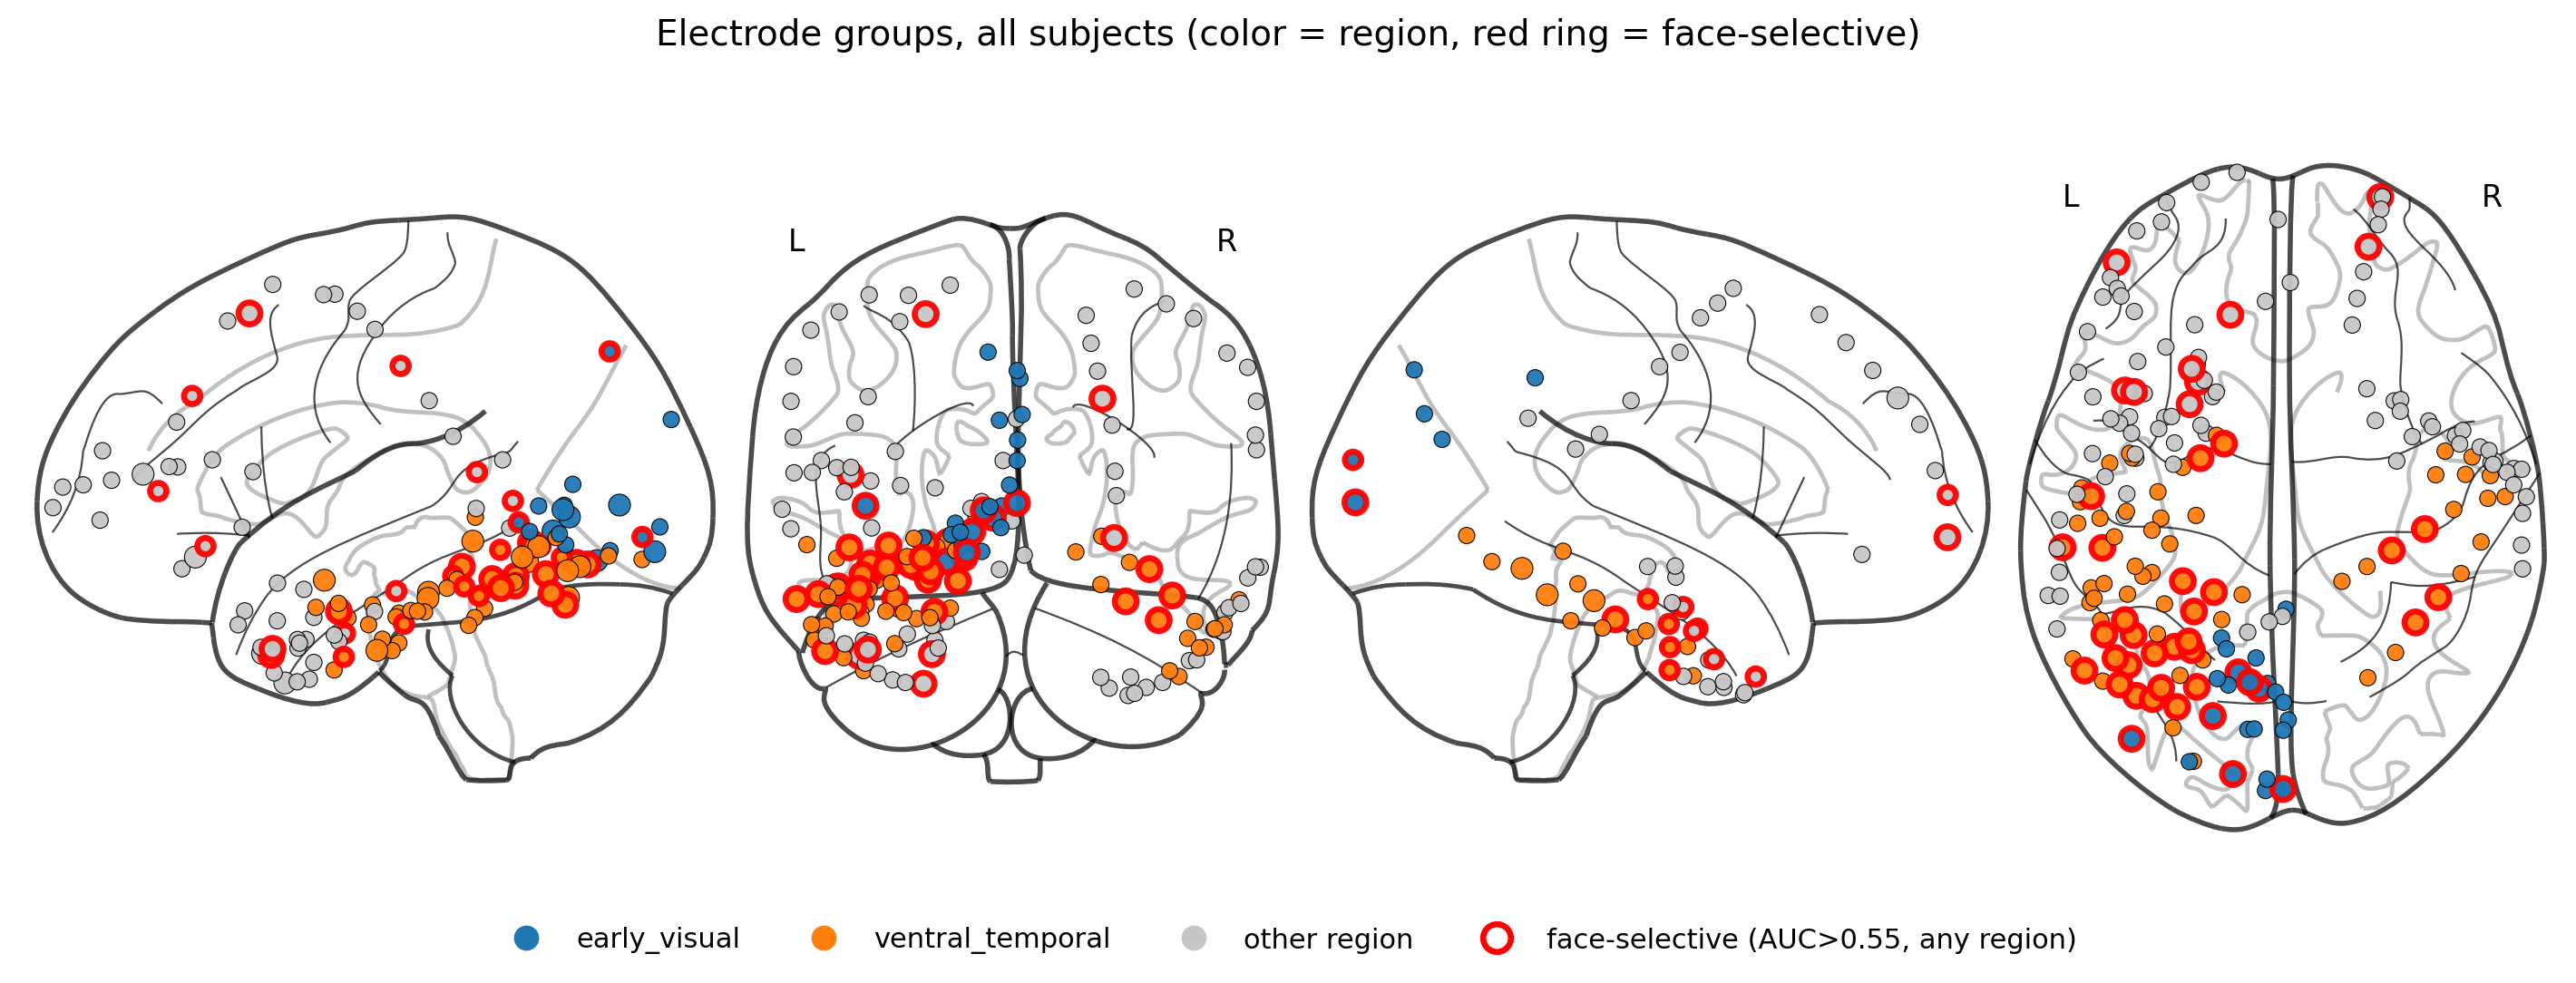

Total electrodes plotted: 193
  early_visual      : n= 24  (face-selective within this region: 7)
  ventral_temporal  : n= 77  (face-selective within this region: 28)
  other             : n= 92  (face-selective within this region: 9)
  face-selective total (any region): 44


In [6]:
# @title Electrode groups on the brain: early_visual / ventral_temporal / face_selective (presentation-ready)
from nilearn import plotting
from nimare import utils
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

# --- gather electrode coordinates + group membership across all subjects ---
FACE_SEL_THRESH = 0.55   # matches the face_selective definition used in GROUP_NAMES throughout the notebook

coords, region_cat, is_fs = [], [], []
for s in usable:
    d2 = alldat[s][1]
    locs = d2['locs']
    sub = electrode_type_df[electrode_type_df['subject'] == s].set_index('channel')
    for ch in range(locs.shape[0]):
        if np.all(locs[ch] == 0) or ch not in sub.index:
            continue   # no valid location, or electrode wasn't characterized
        row = sub.loc[ch]
        coords.append(locs[ch])
        region_cat.append(row['region'] if row['region'] in ('early_visual', 'ventral_temporal') else 'other')
        is_fs.append(bool(np.isfinite(row['auc_face_low_noise'])) and row['auc_face_low_noise'] > FACE_SEL_THRESH)

coords = np.array(coords)
coords_mni = utils.tal2mni(coords)
region_cat = np.array(region_cat)
is_fs = np.array(is_fs)

# --- base color = anatomical region; face-selective electrodes get a red ring on top (this is how overlap is handled) ---
REGION_CODE = {'early_visual': 0, 'ventral_temporal': 1, 'other': 2}
palette = ['#1f77b4', '#ff7f0e', '#c7c7c7']   # blue / orange / light grey
node_codes = np.array([REGION_CODE[r] for r in region_cat])

fig = plt.figure(figsize=(14, 5), facecolor='white')
disp = plotting.plot_markers(
    node_codes, coords_mni,
    node_size=[75 if fs else 42 for fs in is_fs],
    node_cmap=ListedColormap(palette), node_vmin=-0.5, node_vmax=2.5,
    display_mode='lyrz', colorbar=False, alpha=0.95,
    node_kwargs={'edgecolors': ['red' if fs else 'black' for fs in is_fs],
                 'linewidths': [2.4 if fs else 0.4 for fs in is_fs]},
    figure=fig,
)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[0], markersize=11, label='early_visual'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[1], markersize=11, label='ventral_temporal'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[2], markersize=11, label='other region'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor='red', markeredgewidth=2.4,
           markersize=11, label=f'face-selective (AUC>{FACE_SEL_THRESH}, any region)'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Electrode groups, all subjects (color = region, red ring = face-selective)', fontsize=14, y=1.03)

display(Image(save_fig(fig, '02_electrode_characterization_fig01')))

print(f"Total electrodes plotted: {len(coords)}")
for r in ['early_visual', 'ventral_temporal', 'other']:
    n = (region_cat == r).sum()
    n_fs = ((region_cat == r) & is_fs).sum()
    print(f"  {r:<18}: n={n:>3}  (face-selective within this region: {n_fs})")
print(f"  face-selective total (any region): {is_fs.sum()}")

In [7]:
save_cache('02_electrode_characterization', dat1_visual_df=dat1_visual_df, electrode_type_df=electrode_type_df)


Cached ['dat1_visual_df', 'electrode_type_df'] -> C:\Users\janak\GitHub\noisy-faces-brain-vs-cnn\cache\02_electrode_characterization.pkl


'C:\\Users\\janak\\GitHub\\noisy-faces-brain-vs-cnn\\cache\\02_electrode_characterization.pkl'